In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.Series([1, np.nan, 3.5, np.nan, 7])
data.dropna()
data[data.notna()]

0    1.0
2    3.5
4    7.0
dtype: float64

In [3]:
data = pd.DataFrame([[1., 6.5, 3.], [1., np.nan, np.nan],
                         [np.nan, np.nan, np.nan], [np.nan, 6.5, 3.]])
data.dropna()
data.dropna(how="all")
data.dropna(axis="columns", how="all")


,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


In [4]:
df = pd.DataFrame(np.random.standard_normal((7, 3)))
df
df.iloc[:4, 1] = np.nan
df.iloc[:2, 2] = np.nan
df
df.dropna()
df.dropna(thresh=2)
df.fillna({1: 0.5, 2: 0})
data.fillna(data.mean())


,0,1,2
0,1.0,6.5,3.0
1,1.0,6.5,3.0
2,1.0,6.5,3.0
3,1.0,6.5,3.0


In [5]:
data = pd.DataFrame({"k1": ["one", "two"] * 3 + ["two"],
                    "k2": [1, 1, 2, 3, 3, 4, 4]})
data.duplicated()
data.drop_duplicates()

,k1,k2
0,one,1
1,two,1
2,one,2
3,two,3
4,one,3
5,two,4


In [6]:
data = pd.DataFrame({"food": ["bacon", "pulled pork", "bacon",
                    "pastrami", "corned beef", "bacon",
                    "pastrami", "honey ham", "nova lox"],
                    "ounces": [4, 3, 12, 6, 7.5, 8, 3, 5, 6]})
data
meat_to_animal = {
  "bacon": "pig",
  "pulled pork": "pig",
  "pastrami": "cow",
  "corned beef": "cow",
  "honey ham": "pig",
  "nova lox": "salmon"
}
# data["animal"] = data["food"].map(meat_to_animal)
# data
def get_animal(x):
    return meat_to_animal[x]
data["food"].map(get_animal)


0       pig
1       pig
2       pig
3       cow
4       cow
5       pig
6       cow
7       pig
8    salmon
Name: food, dtype: object

In [7]:
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 41, 32]
bins = [18, 25, 35, 60, 100]
age_categories = pd.cut(ages, bins)
age_categories


[(18, 25], (18, 25], (18, 25], (25, 35], (18, 25], ..., (25, 35], (60, 100], (35, 60], (35, 60], (25, 35]]
Length: 12
Categories (4, interval[int64, right]): [(18, 25] < (25, 35] < (35, 60] < (60, 100]]

In [8]:
data = pd.DataFrame(np.random.standard_normal((1000, 4)))
data.describe()


,0,1,2,3
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.034550,0.001437,-0.014507,0.093550
std,0.950773,0.970740,1.006111,0.961272
min,-2.800503,-3.882252,-3.084265,-2.784318
25%,-0.686350,-0.647218,-0.689991,-0.563589
50%,-0.043472,-0.016235,-0.008783,0.093226
75%,0.586772,0.697198,0.644240,0.702719
max,3.026801,3.287475,3.575266,3.358200


In [9]:
df = pd.DataFrame({"key": ["b", "b", "a", "c", "a", "b"],
                 "data1": range(6)})
df
dummies = pd.get_dummies(df["key"], prefix="key")
df_with_dummy = df[["data1"]].join(dummies)
df_with_dummy

,data1,key_a,key_b,key_c
0,0,False,True,False
1,1,False,True,False
2,2,True,False,False
3,3,False,False,True
4,4,True,False,False
5,5,False,True,False


In [10]:
df1 = pd.DataFrame({"key": ["b", "b", "a", "c", "a", "a", "b"],
              "data1": pd.Series(range(7), dtype="Int64")})
df1
df2 = pd.DataFrame({"key": ["a", "b", "d"],
                     "data2": pd.Series(range(3), dtype="Int64")})
df2

pd.merge(df1, df2, on = "key")


,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


In [11]:
df3 = pd.DataFrame({"lkey": ["b", "b", "a", "c", "a", "a", "b"],
                        "data1": pd.Series(range(7), dtype="Int64")})

df4 = pd.DataFrame({"rkey": ["a", "b", "d"],
                        "data2": pd.Series(range(3), dtype="Int64")})

pd.merge(df3, df4, left_on="lkey", right_on="rkey")

,lkey,data1,rkey,data2
0,b,0,b,1
1,b,1,b,1
2,a,2,a,0
3,a,4,a,0
4,a,5,a,0
5,b,6,b,1


In [12]:
pd.merge(df1, df2, how="outer")

,key,data1,data2
0,a,2,0
1,a,4,0
2,a,5,0
3,b,0,1
4,b,1,1
5,b,6,1
6,c,3,<NA>
7,d,<NA>,2


In [13]:
import matplotlib.pyplot as plt


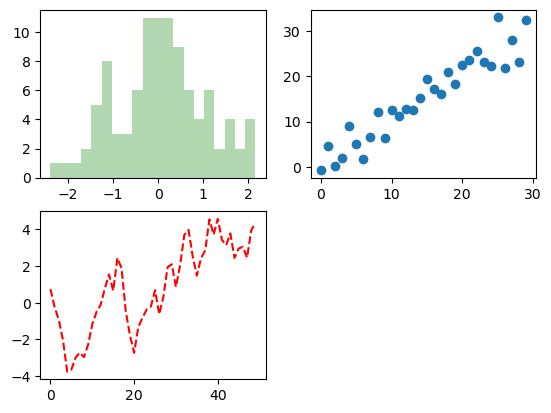

In [14]:
data = np.arange(10)
data
# plt.plot(data)
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1) 
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax1.hist(np.random.standard_normal(100), bins=20, color="green", alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
ax3.plot(np.random.standard_normal(50).cumsum(), color="red",
           linestyle="dashed")


[Text(0.5, 1.0, 'My first matplotlib plot'), Text(0.5, 0, 'Stages')]

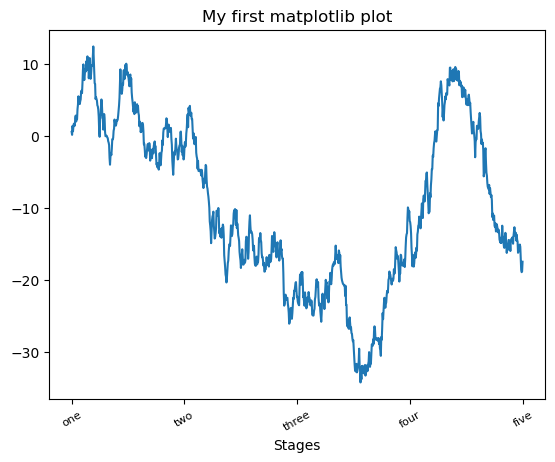

In [ ]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum());
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
abels = ax.set_xticklabels(["one", "two", "three", "four", "five"],
        rotation=30, fontsize=8)
ax.set_xlabel("Stages")
ax.set(title="My first matplotlib plot", xlabel="Stages")


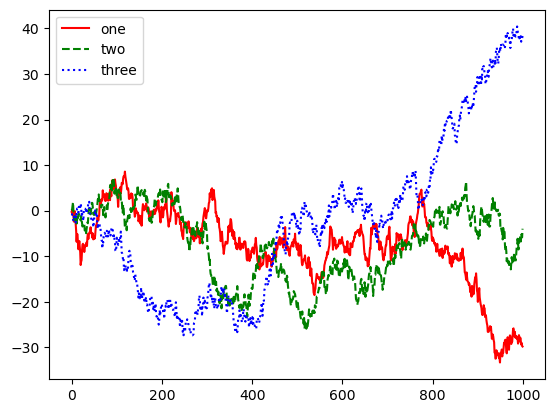

In [22]:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="red", label="one");
ax.plot(np.random.randn(1000).cumsum(), 
        color="green", linestyle="dashed",
        label="two");
ax.plot(np.random.randn(1000).cumsum(), color="blue",
         linestyle="dotted",  label="three");
ax.legend()

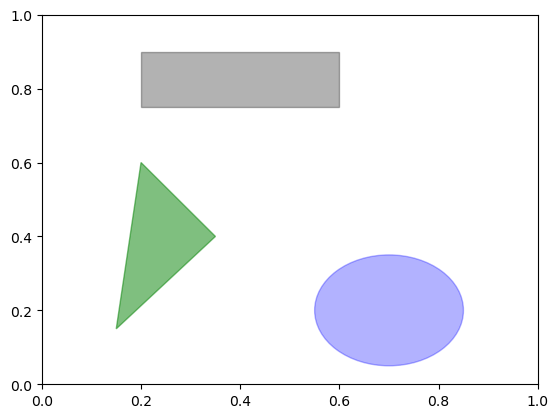

In [25]:
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color="black", alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color="green", alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
fig.savefig("figpath.svg")

<Axes: >

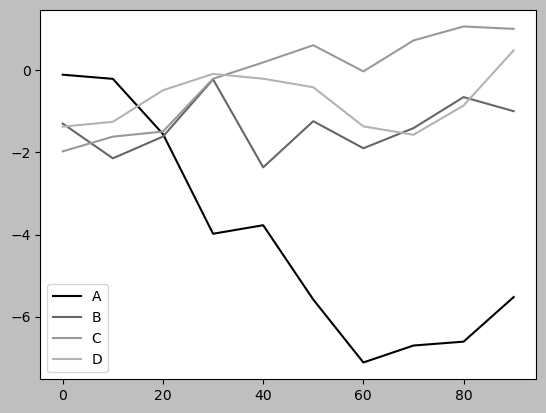

In [27]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                columns=["A", "B", "C", "D"],
                index=np.arange(0, 100, 10))

plt.style.use('grayscale')
df.plot()

<Axes: >

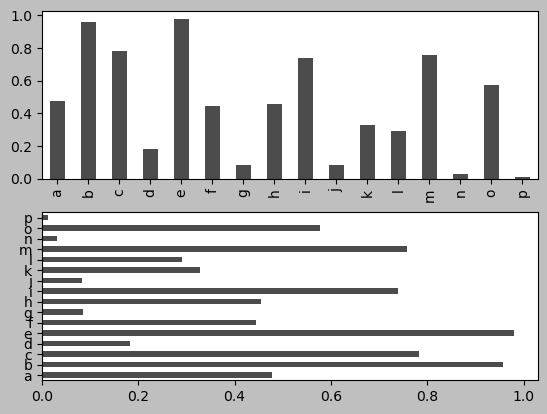

In [29]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)

In [31]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
            index=["one", "two", "three", "four", "five", "six"],
            columns=pd.Index(["A", "B", "C", "D"], name="Genus"))

df

Genus,A,B,C,D
one,0.178556,0.783264,0.530568,0.238357
two,0.742539,0.248170,0.644233,0.265430
three,0.805862,0.141616,0.138758,0.697431
four,0.462517,0.259132,0.068866,0.378487
five,0.016879,0.803401,0.594607,0.185298
six,0.662022,0.931890,0.032911,0.206818


<Axes: >

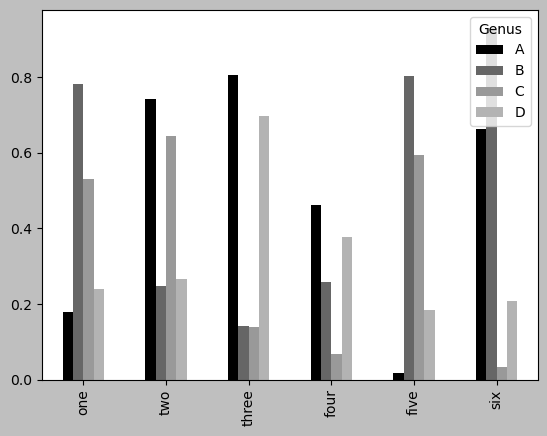

In [32]:
df.plot.bar()

<Axes: >

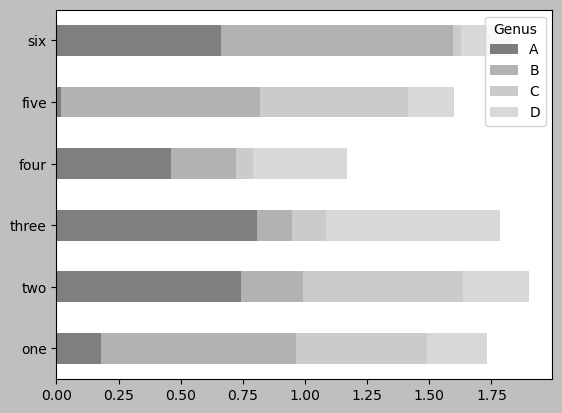

In [33]:
df.plot.barh(stacked=True, alpha=0.5)